In [1]:
import dhlab as dh
from dhlab.api.dhlab_api import totals
from dhlab import nbtext as nb

In [2]:
# korpus med inntil 50 bøker fra dewey 641 (mat og drikke) utgitt mellom 1960 og 2020

korpus = dh.Corpus(ddk="641*", doctype="digibok", limit=50)

In [3]:
korpus.corpus.head(2)

,dhlabid,urn,title,authors,oaiid,sesamid,isbn10,city,timestamp,year,publisher,langs,subjects,ddc,genres,literaryform,doctype,ocr_creator,ocr_timestamp
0,100434334,URN:NBN:no-nb_digibok_2021020405043,Fristelser fra fjellet : tradisjon og innovasj...,"Forselius , Mikael / Veldhuis , Rob / Hindklev...",oai:nb.bibsys.no:991027974634702202,887ac59769f96f09cc48686805ea4ef8,,,20100101,2010,Breidablikk forl.,nob,kokebøker / oppskrifter / røros / sør-trøndela...,641.5 / 641.5948414,,Faglitteratur,digibok,nb,20060101
1,100019423,URN:NBN:no-nb_digibok_2010041903044,Smart mat : 90 retter for unge kokker,"Weiland , Agneta / Björnstjerna , Fabian / Hul...",oai:nb.bibsys.no:999815186644702202,866313b4f9193d035145a232e94892e9,8251616786 / 8252533418,Oslo,19980101,1998,Schibsted,nob / swe,Kokebøker / matlaging / kokebøker / ungdom,641.51,,Faglitteratur,digibok,nb,20060101


In [4]:
collword = 'rødvin'

In [5]:
# Vi utfører en konkordans for å sjekke at korpuset virker.
# dh.Concordance(corpus=korpus, query="sei").show()
korpus.conc("sei").show()

,link,concordance
40,URN:NBN:no-nb_digibok_2020091507536,Sei og Poteter i Lag med Løkmarmelade
31,URN:NBN:no-nb_digibok_2007080300069,"... Dypfrysing er enkfo ^ nerSevannefslås lest ' men SO PP kan bli litt sei S - Sjampinjonger , vekk . kantareller..."
22,URN:NBN:no-nb_digibok_2007072704081,"Annen fisk - Torsk , sei , kolje og kveite kan tilberedes på samme måte . Vi trenger ikke marinere..."
15,URN:NBN:no-nb_digibok_2018090607099,"SEI I EIN E0RM Sei er fremdeles vilIfanget , i motsetning til laks og torsk som i hovedsak er oppdrett..."
4,URN:NBN:no-nb_digibok_2022110148044,"... Ho kuinn og sei at vi mått aldri , ALLER ta imot godter av fremmede menn . Huska at æ..."
35,URN:NBN:no-nb_digibok_2013031206014,"Vi kan bruke sei , makrell , sild , laks eller aure ."
48,URN:NBN:no-nb_digibok_2007080300069,... Ssl kolje séi / rødl Bere § n 150 - 175 g fiskefilet eller 200 - 250 g fiskeskiver pr. spette...
51,URN:NBN:no-nb_digibok_2007041901080,"... , haler av hellefisk , flyndre , ja endog sei og kolje . Berggylt var det visstnok også i en..."
27,URN:NBN:no-nb_digibok_2018090607099,Sei i fin form 138
26,URN:NBN:no-nb_digibok_2022110148044,"... sa "" No må dokker oppfør dokker , eller så sei e i fra tell tam dokkers ! "" ( noe jeg..."


In [6]:
# Vi legger inn variablen collword som søkeord, med 5 ord før og etter. 
#  Antall ord før og etter kan endres etter konteksten man vil undersøke.
# Collword er lagt som variabel i cella over, slik at det er lett å gjenbruke notebooken for ulike søkeord

coll = korpus.coll(words=collword, after=5, before=5, samplesize=1000)

In [7]:
# For å vise topp `n` treff bruke .show().head(n)
coll.show().head(5)

,counts
",",151
.,90
og,84
1,79
dl,72


In [8]:
coll.coll.sort_values(by="counts", ascending=False).head(10)

,counts
",",151
.,90
og,84
1,79
dl,72
en,56
i,47
med,45
2,43
eller,42


In [9]:
tot = totals(50000)

In [10]:
tot.head()

,freq
.,7655423257
",",5052171514
i,2531262027
og,2520268056
-,1314451583


In [11]:
# dh.Counts teller tokens i hver tekst i korpus
dokumenter_aggregert = korpus.count(words=None)

In [12]:
# Summerer slik at vi får totalt tokens for korpus
korpus_agg = dokumenter_aggregert.counts.sum(axis=1)

In [13]:
korpus_agg = nb.frame_sort(nb.frame(korpus_agg))

In [14]:
korpus_agg.head(10)

,0
.,118115
",",94061
og,70448
i,60257
med,30812
til,26041
en,25150
er,23468
på,22177
av,21601


In [15]:
coll.coll.sort_values(by="counts", ascending=False)

,counts
",",151
.,90
og,84
1,79
dl,72
...,...
fruktene,1
Chablis,1
frøene,1
fugl,1


In [16]:
coll_df = coll.coll.copy()

In [17]:
coll_df.sort_values(by="counts", ascending=False)

,counts
",",151
.,90
og,84
1,79
dl,72
...,...
fruktene,1
Chablis,1
frøene,1
fugl,1


In [18]:
nb.normalize_corpus_dataframe(korpus_agg)
nb.normalize_corpus_dataframe(tot)
nb.normalize_corpus_dataframe(coll_df)

True

In [19]:
korpus_agg.head()

,0
.,0.055636
",",0.044306
og,0.033183
i,0.028383
med,0.014513


In [20]:
tot.head()

,freq
.,0.070908
",",0.046796
i,0.023446
og,0.023344
-,0.012175


In [21]:
coll.coll.head()

,counts
!,3
"""",2
%,3
',1
(,20


In [22]:
coll_assoc = (coll_df.counts**1.0/tot.freq).sort_values(ascending=False).to_frame()

In [23]:
coll_assoc.head(20)

,0
hvitvin,3017.204553
dl,1358.500106
timian,1188.609238
eddik,1126.581861
Tilsett,1070.681744
Server,1027.223141
selleri,1017.996541
burgunder,1011.815827
hermetiske,766.407495
Kokt,754.737753


In [24]:
korpus_agg

,0
.,0.055636
",",0.044306
og,0.033183
i,0.028383
med,0.014513
...,...
grunnsmak,0.0
eplesaftkonsentrat,0.0
Redaksjon,0.0
Much,0.0


In [25]:
coll_assoc_korp = (coll_df.counts**1.2/korpus_agg.iloc[:, 0]).sort_values().to_frame()

In [26]:
coll_assoc_korp.head(20)

,0
minutter,0.027238
',0.030309
*,0.037609
■,0.043618
seg,0.048333
også,0.053953
Legg,0.055274
et,0.055815
skal,0.056467
^,0.057476


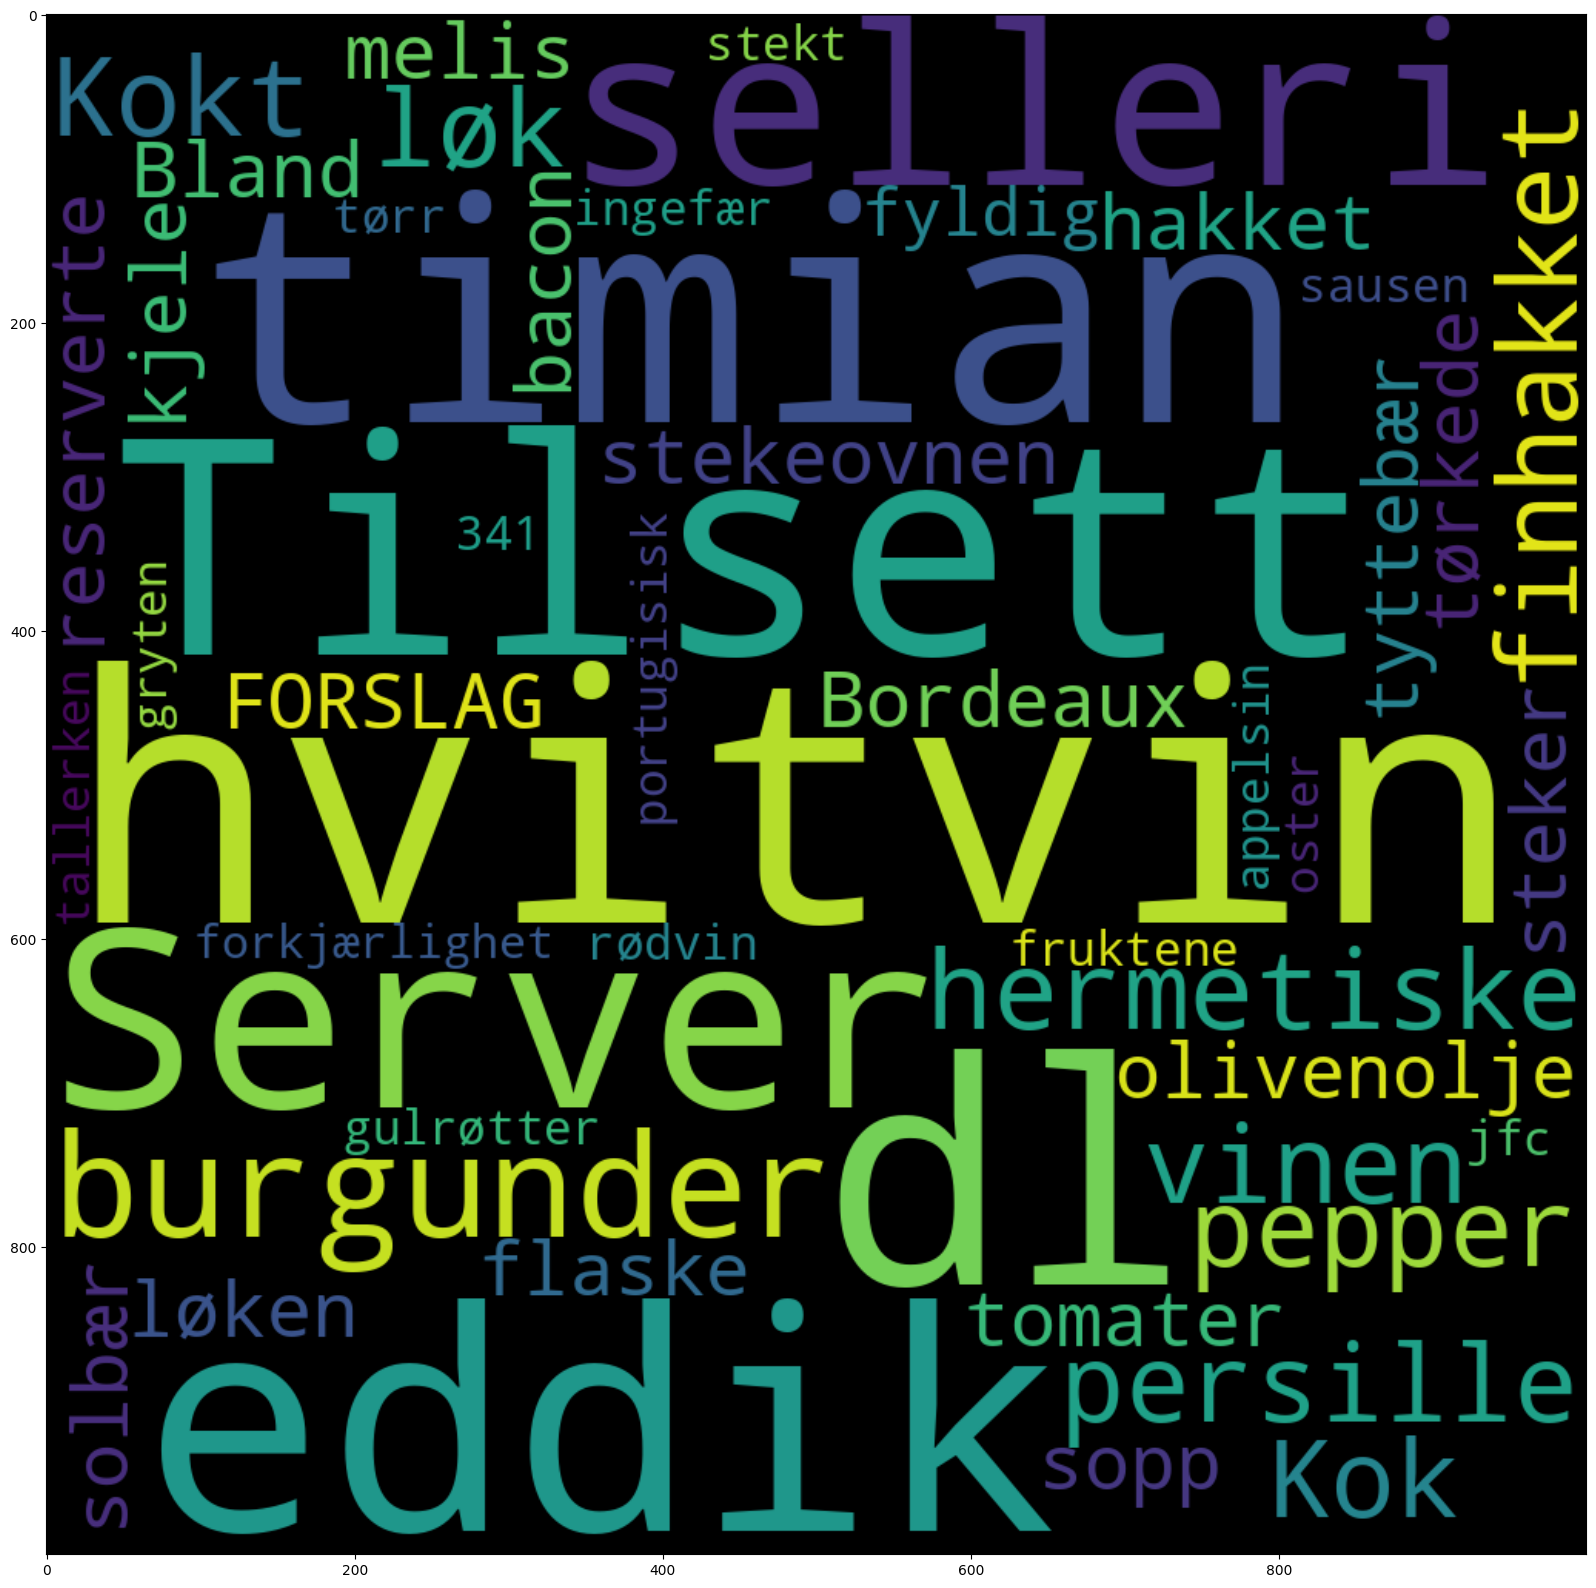

In [27]:
# Her viser vi de 50 viktigste ordene som er assosiert med rødvin i korpuset vårt, målt mot alle bøker i nb.no 

nb.cloud(coll_assoc.head(50)/coll_assoc.sum())

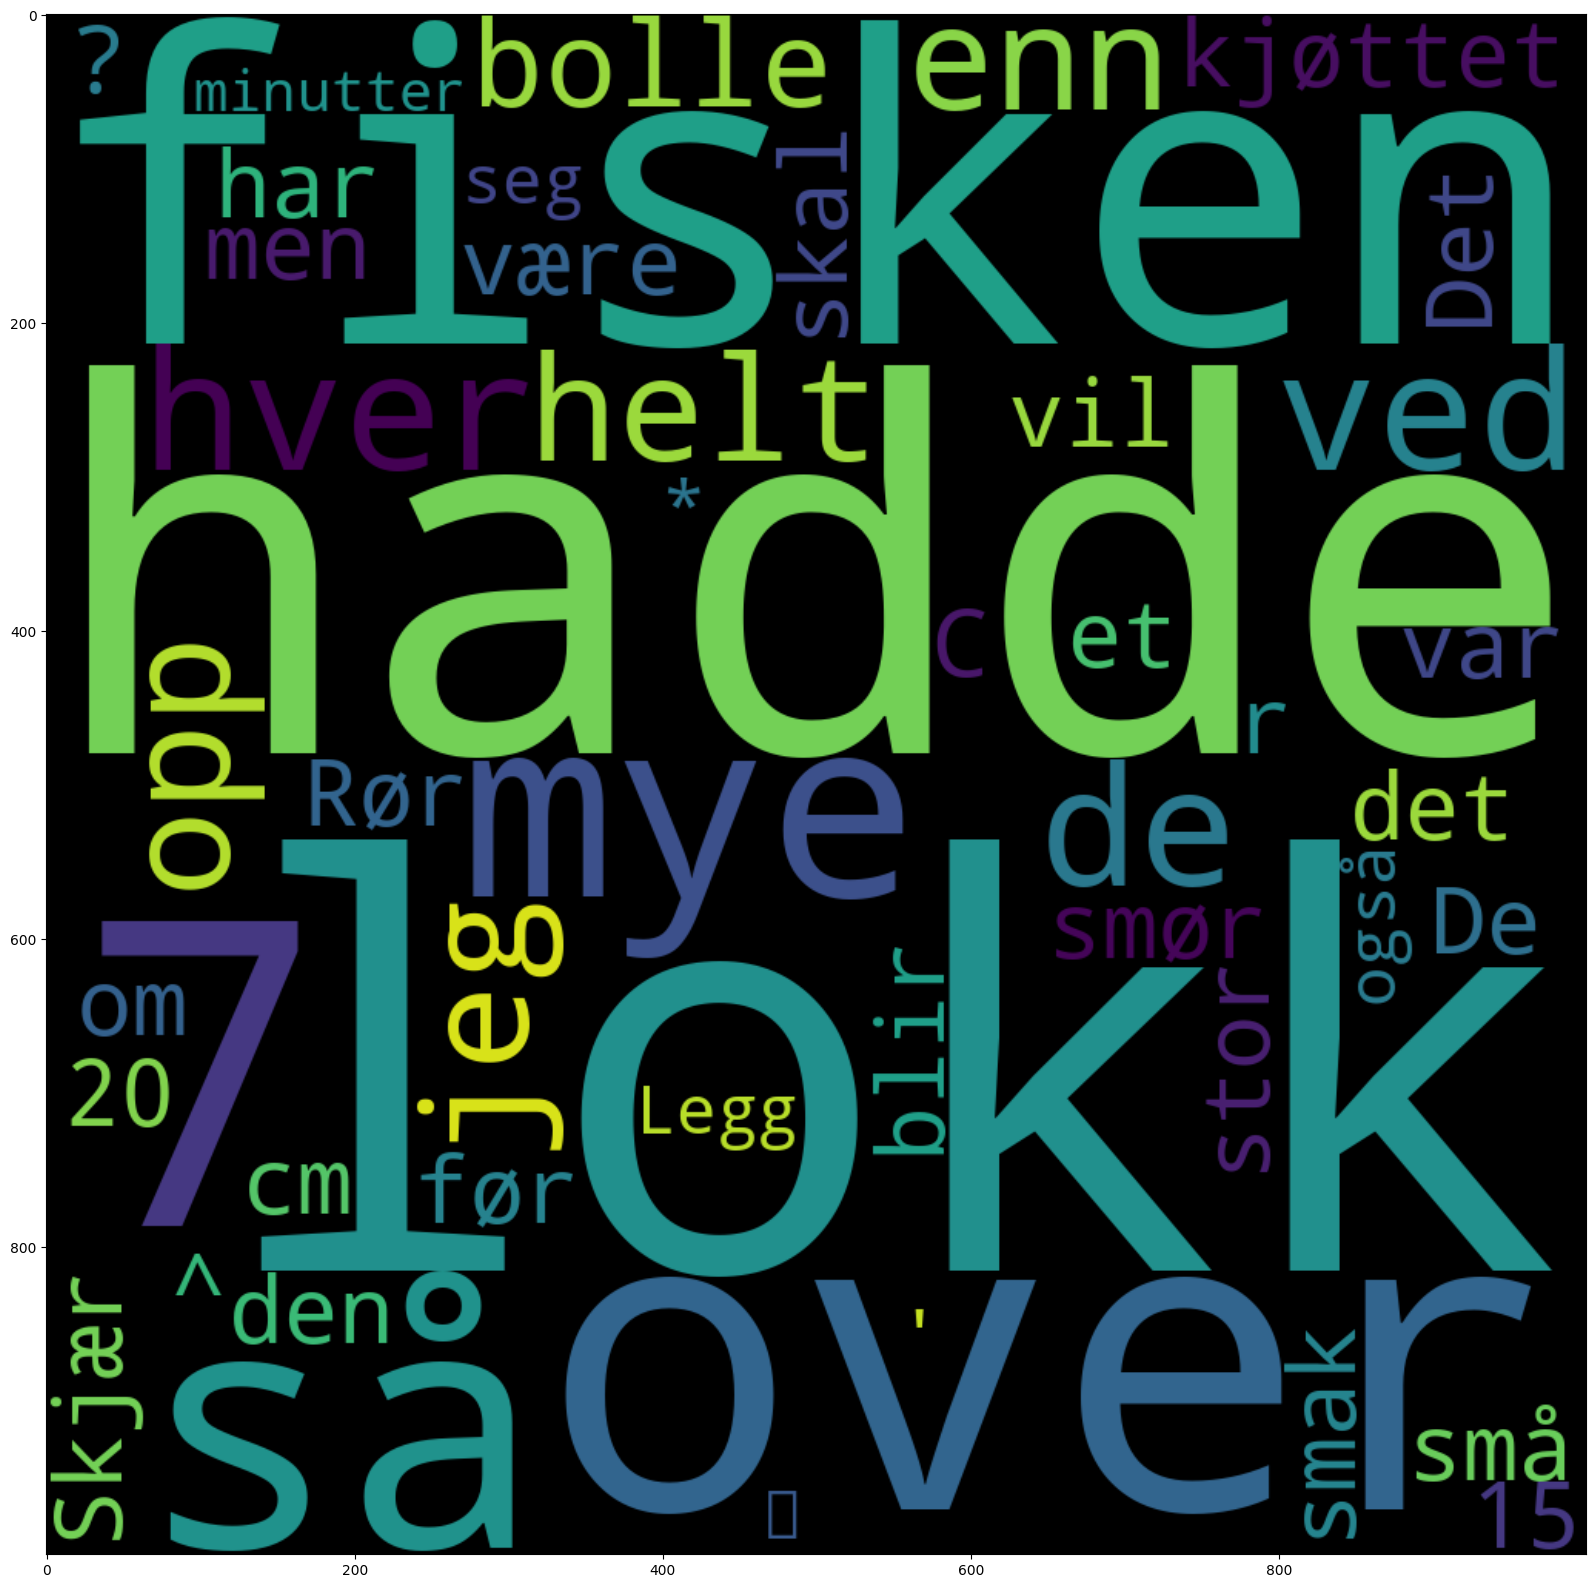

In [28]:
# Her viser vi de 50 viktigste ordene som er assosiert med rødvin, målt mot hele "Drikkevare"-korpuset

nb.cloud(coll_assoc_korp.head(50)/coll_assoc_korp.sum())